<a href="https://colab.research.google.com/github/orcasandpandas/Data-Science-Cohort-20/blob/main/Project_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 6: Image Classification with Deep Learning



This project introduces us to deep learning. The deep learning process is a huge leap forward in data science and the field is less than 15 years old. The processing is significantly different from our previous projects so you will basically be provided a walkthrough document delineating the steps - much like Project 1. Deep learning is fascinating and I just want you to go through the process so you can appreciate its power.



The data collection portion of deep learning projects is a rather complex task. In other words, there is no CSV file that we can load to serve as our training data. Constructing a training data set is a rather large undertaking. We have imported all the training images (took hours) and I will show you how you can load the training data through the "pickle" process.



There are three files in this data set:
- [the feature set]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle ), i.e. images of dogs and cats ( mostly )
- [the target set]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle ), i.e. the label (0/1) that something is a dog or cat ( mostly )
- [a test image]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg )





This project will classify new, unseen images of cats and dogs. This was one of the first big success stories of deep learning and we will go through the process of building a learning algorithm that will do this task. Distinguishing a picture of a cat from a picture of a dog is easy for humans to do, but had been notoriously difficult to get a computer learning to perform well on the task. Deep learning solved that.  Some extraneous images will also be tested.


## Data Loading

In [3]:
import tensorflow.keras as keras
import tensorflow as tf
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from keras.models import Sequential
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPooling2D
from keras.utils import plot_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


Here, the standard Data Science modules are imported along with the models needed for a neural network.

In [ ]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [ ]:
# Unpickles or reads our images
image_array = pd.read_pickle( images_url )
type(image_array)


In [ ]:
# Normalize the image to black and white by diving by 255!
image_array = image_array / 255.0
image_array

In [ ]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url


In [ ]:
# Unpickle the targets
target = pd.read_pickle( target_url )
type(target)


Pickling essentially converts an object to byte form, so unpickling reads that.  We also need to make sure target is a numpy array later.

## Exploratory Data Analysis

In [ ]:
image_array.shape

In [ ]:
target = np.array(target)
target.shape

We've turned the target into a 2d array, allow it to be input into the model.
Also of note: The first dimension of the target and image array are both the same, meaning each predictor data point has a matching target for it.

In [ ]:
for i in range(6):

  print(target[i])
  plt.imshow(image_array[i])
  plt.show()

By loading some of our dataset, we can see what we are working with!

Note that the images are actually monochrome, matplotlib's imshow() function just defaults to showing a yellow and green gradient

## Data Processing

In [ ]:
# Splitting into training and testing sets
X_train, X_test, y_train, y_test = train_test_split( image_array, target, test_size = 0.2 )


In [ ]:
# We're using a sequential model for this assignment
model = Sequential()


Note: a sequential model is one of the simpler ones and has data from one layer directing flowing to the next one

### Input Layer of the model

In [ ]:
# Define input layer
model.add(
  Input(
    shape=X_train.shape[1:],
    name="model_input",
  ),
)

# This helps improve performance
model.add(
    MaxPooling2D(pool_size=(2,2))
)

The input layer's shape is the same as the dimensions of each image, hence we get the 2nd dimension forwards as the 1st dimension indicates the number of the image.



### Hidden Layers

In [ ]:
# Define first hidden layer
model.add(
  Conv2D(
    name = "Conv1",
    filters = 32,
    kernel_size = (3,3),
    # Rectified Linear Unit outputs the input directly if positive and 0 otherwise
    activation = 'relu',
  )
)

model.add(
  MaxPooling2D(pool_size=(2,2))
)


In [ ]:
# Define second hidden layer
model.add(
  Conv2D(
    name = "Conv2",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
  MaxPooling2D(pool_size=(2,2))
)


In [ ]:
# Define third hidden layer
model.add(
  Conv2D(
    name = "Conv3",
    filters = 128,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
  MaxPooling2D(pool_size=(2,2))
)


A convolutional model is the standard for neural networks typically.  The hidden layers are what do the actual calculation, and the amount of filters was doubled per layer; this is because each layer usually has to capture more complex patterns than the last!

Model Output

In [ ]:
# Flatten data to be used in output layer
model.add(
    Flatten()
)

# Define output layer
model.add(
  Dense(
    name = "output",
    units = 10,
    # Sigmoid activiatoin is ideal for binary outcomes
    activation = 'sigmoid',
  )
)


We're outputting one number, so all our data must be flatted to one dimension!

In [ ]:
# Compile model
model.compile(
  optimizer = 'adam',
  loss = 'sparse_categorical_crossentropy',
  metrics = ['accuracy'],
)


### Model Fitting

In [ ]:
# Fit model
model.fit(
    X_train,
    y_train,
    epochs=8,
    validation_data=(X_test, y_test))

Epoch 1/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 559s 888ms/step - accuracy: 0.6239 - loss: 0.6341 - val_accuracy: 0.7068 - val_loss: 0.5665
Epoch 2/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 539s 864ms/step - accuracy: 0.7673 - loss: 0.4928 - val_accuracy: 0.7836 - val_loss: 0.4609
Epoch 3/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 537s 861ms/step - accuracy: 0.8017 - loss: 0.4335 - val_accuracy: 0.8110 - val_loss: 0.4169
Epoch 4/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 562s 861ms/step - accuracy: 0.8274 - loss: 0.3850 - val_accuracy: 0.8188 - val_loss: 0.4052
Epoch 5/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 570s 874ms/step - accuracy: 0.8446 - loss: 0.3521 - val_accuracy: 0.8248 - val_loss: 0.3948
Epoch 6/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 539s 865ms/step - accuracy: 0.8616 - loss: 0.3214 - val_accuracy: 0.8421 - val_loss: 0.3602
Epoch 7/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 530s 849ms/step - accuracy: 0.8798 - loss: 0.2831 - val_accuracy: 0.8429 - val_loss: 0.3654
Epoch 8/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 538s 863ms/step - accuracy: 0.8919 - loss: 0

Each epoch, the model gets more and more accurate!

## Conclusions

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 47, 47, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │         6,401 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,693 (948.02 KB)

 Trainable params: 80,897 (316.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 161,796 (632.02 KB)

As you can see, the number of parameters increases each layer while the shape of the output gets smaller.

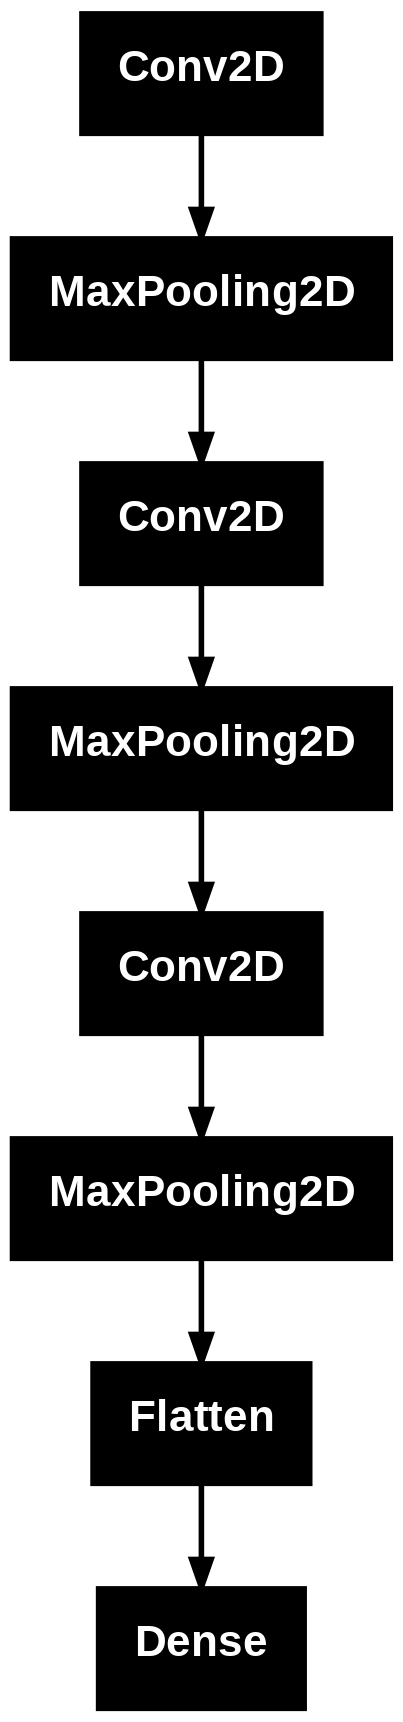

In [ ]:
plot_model(model)

Picture is the flow of how the data goes from one layer to another

In [ ]:
val_loss, val_acc = model.evaluate(X_test, y_test)
print(val_loss)
print(val_acc)

156/156 ━━━━━━━━━━━━━━━━━━━━ 34s 218ms/step - accuracy: 0.8445 - loss: 0.3692
0.36920779943466187
0.8444889783859253


From this showcase, a very desirable accuracy is achieved in our model!

In [ ]:
# Plots the distribution of probabilities from our model

# Lets see what our model may predictor
y_probs = model.predict(X_test)

# Flatten the array so it is a simple 1D list of numbers
y_probs_flat = y_probs.flatten()

# Plot the histogram
plt.figure(figsize=(8, 5))
plt.hist(y_probs_flat, bins=50, color='skyblue', edgecolor='black')

plt.title("Distribution of Predicted Probabilities")
plt.xlabel("Probability Score (0 = likely dog, 1 = likely cat)")
plt.ylabel("Number of Images")
plt.show()

From our graph, it seems the dataset has more dogs than cats, leading to some overfitting towards the dog end of the spectrum.  This means images may be incorrectly identified as looking like a dog more!

## Bonus

(100, 100)

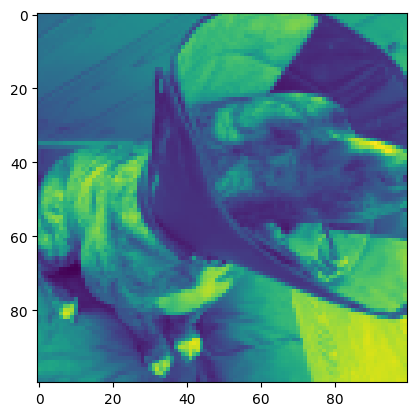

In [9]:
from skimage import io
from skimage.transform import resize

# Loads the picture by URL, importing as monochrome with the param im_gray removes the need to normalize
dog_pic = io.imread("https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg", as_gray = True)

# The model is used to 100 x 100 images, so we must resize our dog pic to that
dog_pic = resize(dog_pic, (100, 100))

# For input the image must be cast to float32
dog_pic = dog_pic.astype("float32")
plt.imshow(dog_pic)

dog_pic.shape

In [ ]:
# Our dog pic needs to be 4d, so lets fix that
dog_pic = dog_pic[None, :, :, None]
dog_pic.shape

In [ ]:
predict_test = model.predict(dog_pic)
# Lets see how good our model is at identifying if there's a dog!
predict_test

In [ ]:
# This function allows an image url to be input and return its confidence
# in whether its a dog or a cat!
def predictor(url)
  pic = io.imread(url, as_gray = True)
  pic = resize(pic,(100,100))
  pic = pic.astype("float32")
  plt.imshow(pic)

  pic = pic[None, :, :, None]
  prediction = model.predict(pic)
  return prediction

Lets see how our model does with a few more test images!

In [ ]:
# Standard Housecat
predictor("https://images.ctfassets.net/r208a72kad0m/MooSrKbLUDMOHCSMfMLO7/bb9694cc579f03383c322eb6488b81a0/Kattraser__1_.png?w=1086&q=100")

In [ ]:
# Longcat
predictor("https://sm.mashable.com/mashable_sea/photo/default/eivcmyhuwaeedc9_sbb1.jpg")

In [ ]:
# An image of a puppy
predictor("https://hips.hearstapps.com/hmg-prod/images/dog-puppy-on-garden-royalty-free-image-1586966191.jpg?crop=0.752xw:1.00xh;0.175xw,0&resize=1200:*")

Just for fun, lets test some images that would fall outside of the model's parameters

In [1]:
# A fox
predictor("https://njaes.rutgers.edu/fs1325/FS1325-1-big.jpg")

NameError: name 'predictor' is not defined

In [ ]:
# Finally, an anime catgirl
predictor("https://play-lh.googleusercontent.com/N26xokw3n4pfBmchwK1CkWzK1RdxyPmrilaCaOB_t8ZzxovP-Axnz_Ks6SxbLkGuzg")

The model did actually lean towards cat when identifying what the catgirl was... still, this shows that when making a model, we must know what purpose it will be used for and what data will be input!  